In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, classification_report, confusion_matrix)

warnings.filterwarnings('ignore')

In [2]:
# Charger les données
df = pd.read_csv("alzheimers_disease_data.csv")

# Afficher les informations de base
print("Forme du jeu de données :", df.shape)
print("\n5 Premières lignes :")
print(df.head())

print("\nTypes de données :/n")
print(df.dtypes)

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

Forme du jeu de données : (2149, 35)

5 Premières lignes :
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   Behavi

In [3]:
# Supprimer les colonnes inutiles
df_clean = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

print(f"Forme du jeu de données après nettoyage : {df_clean.shape}")
print("\nJeu de données nettoyé :")
print(df_clean.head())

Forme du jeu de données après nettoyage : (2149, 33)

Jeu de données nettoyé :
   Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0   73       0          0               2  22.927749        0   
1   89       0          0               0  26.827681        0   
2   73       0          3               1  17.795882        0   
3   74       1          0               1  33.800817        1   
4   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0           13.297218          6.327112     1.347214      9.025679  ...   
1            4.542524          7.619885     0.518767      7.151293  ...   
2           19.555085          7.844988     1.826335      9.673574  ...   
3           12.209266          8.428001     7.435604      8.392554  ...   
4           18.454356          6.310461     0.795498      5.597238  ...   

   FunctionalAssessment  MemoryComplaints  BehavioralProblems       ADL  \
0   

In [4]:
def detect_outliers_iqr(dataframe):
    """
    Détecter les valeurs aberrantes en utilisant la méthode de l'écart interquartile (IQR)
    """
    outlier_indices = []
    
    for col in dataframe.columns[:-1]:  # Sans la colonne cible
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        
        outliers = dataframe[
            (dataframe[col] < Q1 - outlier_step) | 
            (dataframe[col] > Q3 + outlier_step)
        ].index
        
        outlier_indices.extend(outliers)
    
    return list(set(outlier_indices))

# Détecter les valeurs aberrantes
outlier_indices = detect_outliers_iqr(df_clean)
print(f"Nombre de valeurs aberrantes détectées : {len(outlier_indices)}")

Nombre de valeurs aberrantes détectées : 1895


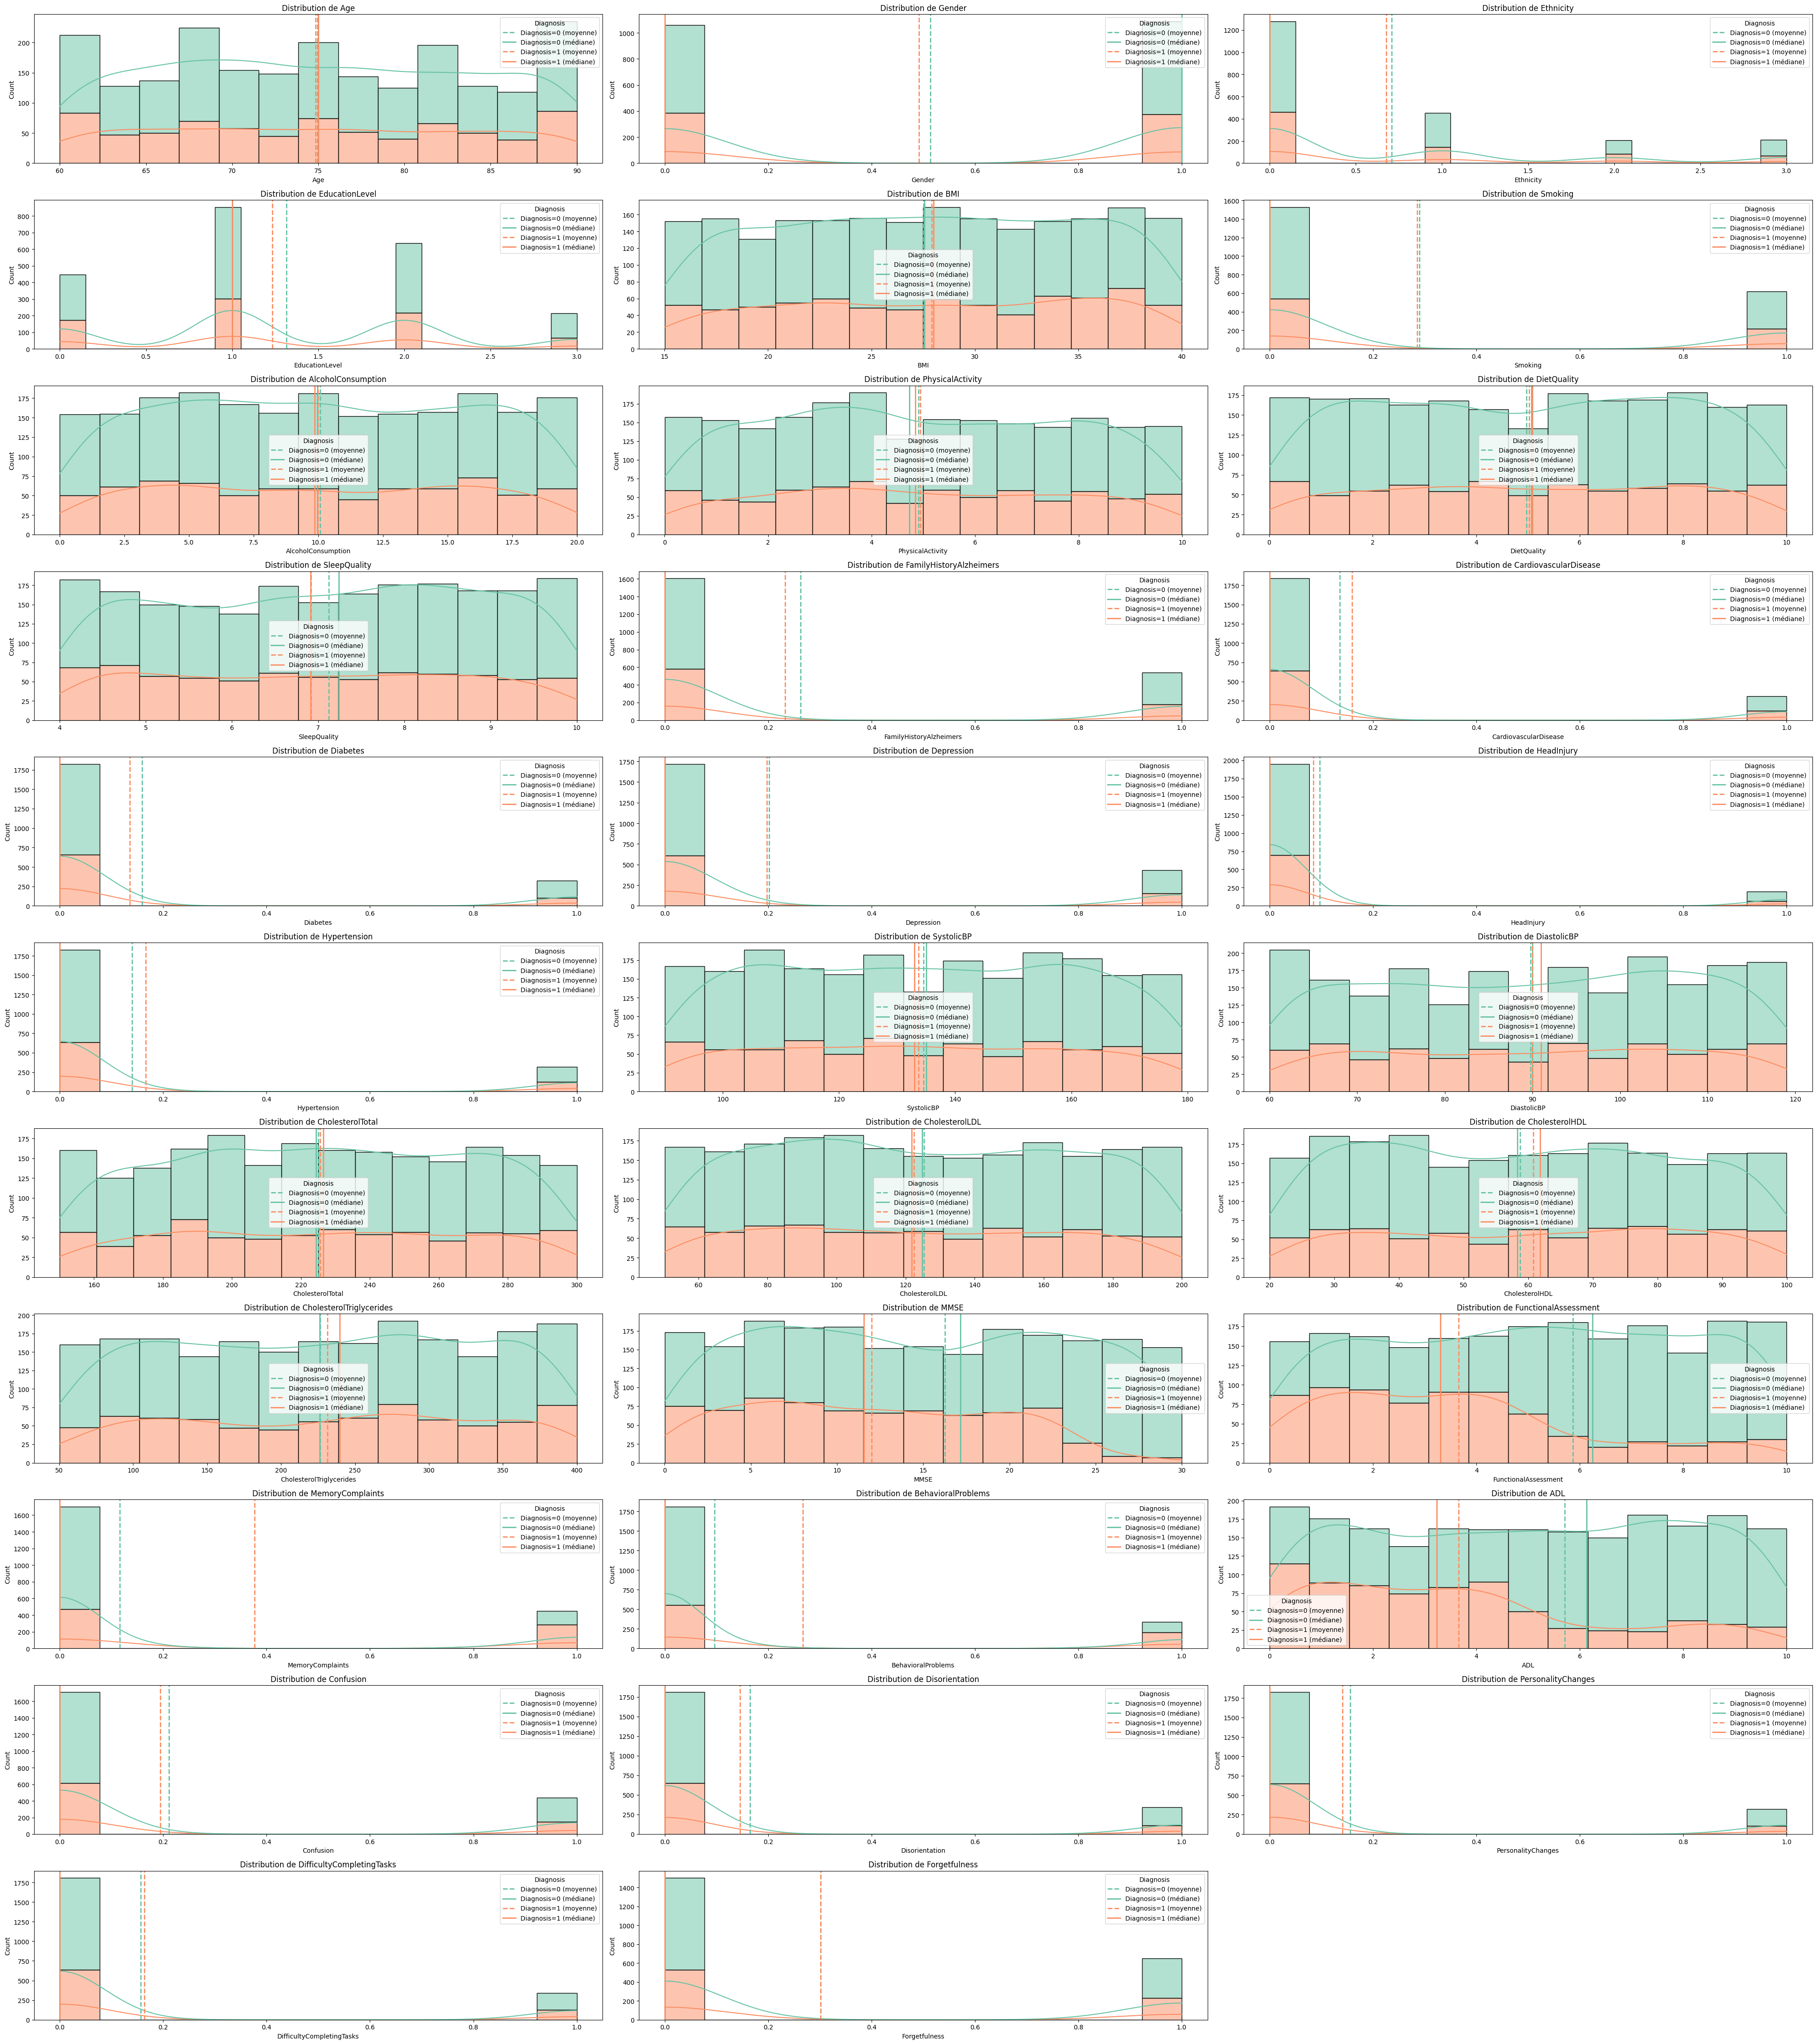

In [5]:
def plot_feature_distributions(dataframe, target_column='Diagnosis', figsize=(40, 45)):
    """
    Trace la distribution avec hue.
    """
    feature_cols = [col for col in dataframe.columns if col != target_column]
    n_features = len(feature_cols)
    n_cols = 3
    n_rows = (n_features // n_cols) + (1 if n_features % n_cols != 0 else 0)

    palette = sns.color_palette("Set2")  # même palette que l’histogramme
    value_to_color = dict(zip(sorted(dataframe[target_column].unique()), palette))

    fig = plt.figure(figsize=figsize)

    for idx, col in enumerate(feature_cols, start=1):
        ax = plt.subplot(n_rows, n_cols, idx)

        # Histogramme
        sns.histplot(
            data=dataframe,
            x=col,
            hue=target_column,
            kde=True,
            palette=value_to_color,
            alpha=0.5,
            ax=ax,
            multiple='stack'
        )

        # Lignes de moyenne et médiane
        for target_value, color in value_to_color.items():
            subset = dataframe[dataframe[target_column] == target_value]
            mean_val = np.mean(subset[col])
            median_val = np.median(subset[col])

            ax.axvline(
                mean_val,
                color=color,
                linestyle='--',
                linewidth=2,
                label=f"{target_column}={target_value} (moyenne)"
            )
            ax.axvline(
                median_val,
                color=color,
                linestyle='-',
                linewidth=2,
                label=f"{target_column}={target_value} (médiane)"
            )

        ax.set_title(f'Distribution de {col}')
        # Fusionner les légendes
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title=f"{target_column}")

    plt.tight_layout()
    plt.show()


# Tracer les distributions
plot_feature_distributions(df_clean)

In [6]:
# Séparer les caractéristiques et la cible
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

# Analyser la distribution des classes
unique_classes, class_counts = np.unique(y, return_counts=True)
print("\nDistribution des classes :")
for cls, count in zip(unique_classes, class_counts):
    print(f"Classe : {cls} | Nombre : {count}")


Distribution des classes :
Classe : 0 | Nombre : 1389
Classe : 1 | Nombre : 760


In [7]:
# Diviser les données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# Standardiser les caractéristiques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Forme de l'ensemble d'entraînement : {X_train_scaled_df.shape}")
print(f"Forme de l'ensemble de test : {X_test_scaled_df.shape}")

Forme de l'ensemble d'entraînement : (1719, 32)
Forme de l'ensemble de test : (430, 32)


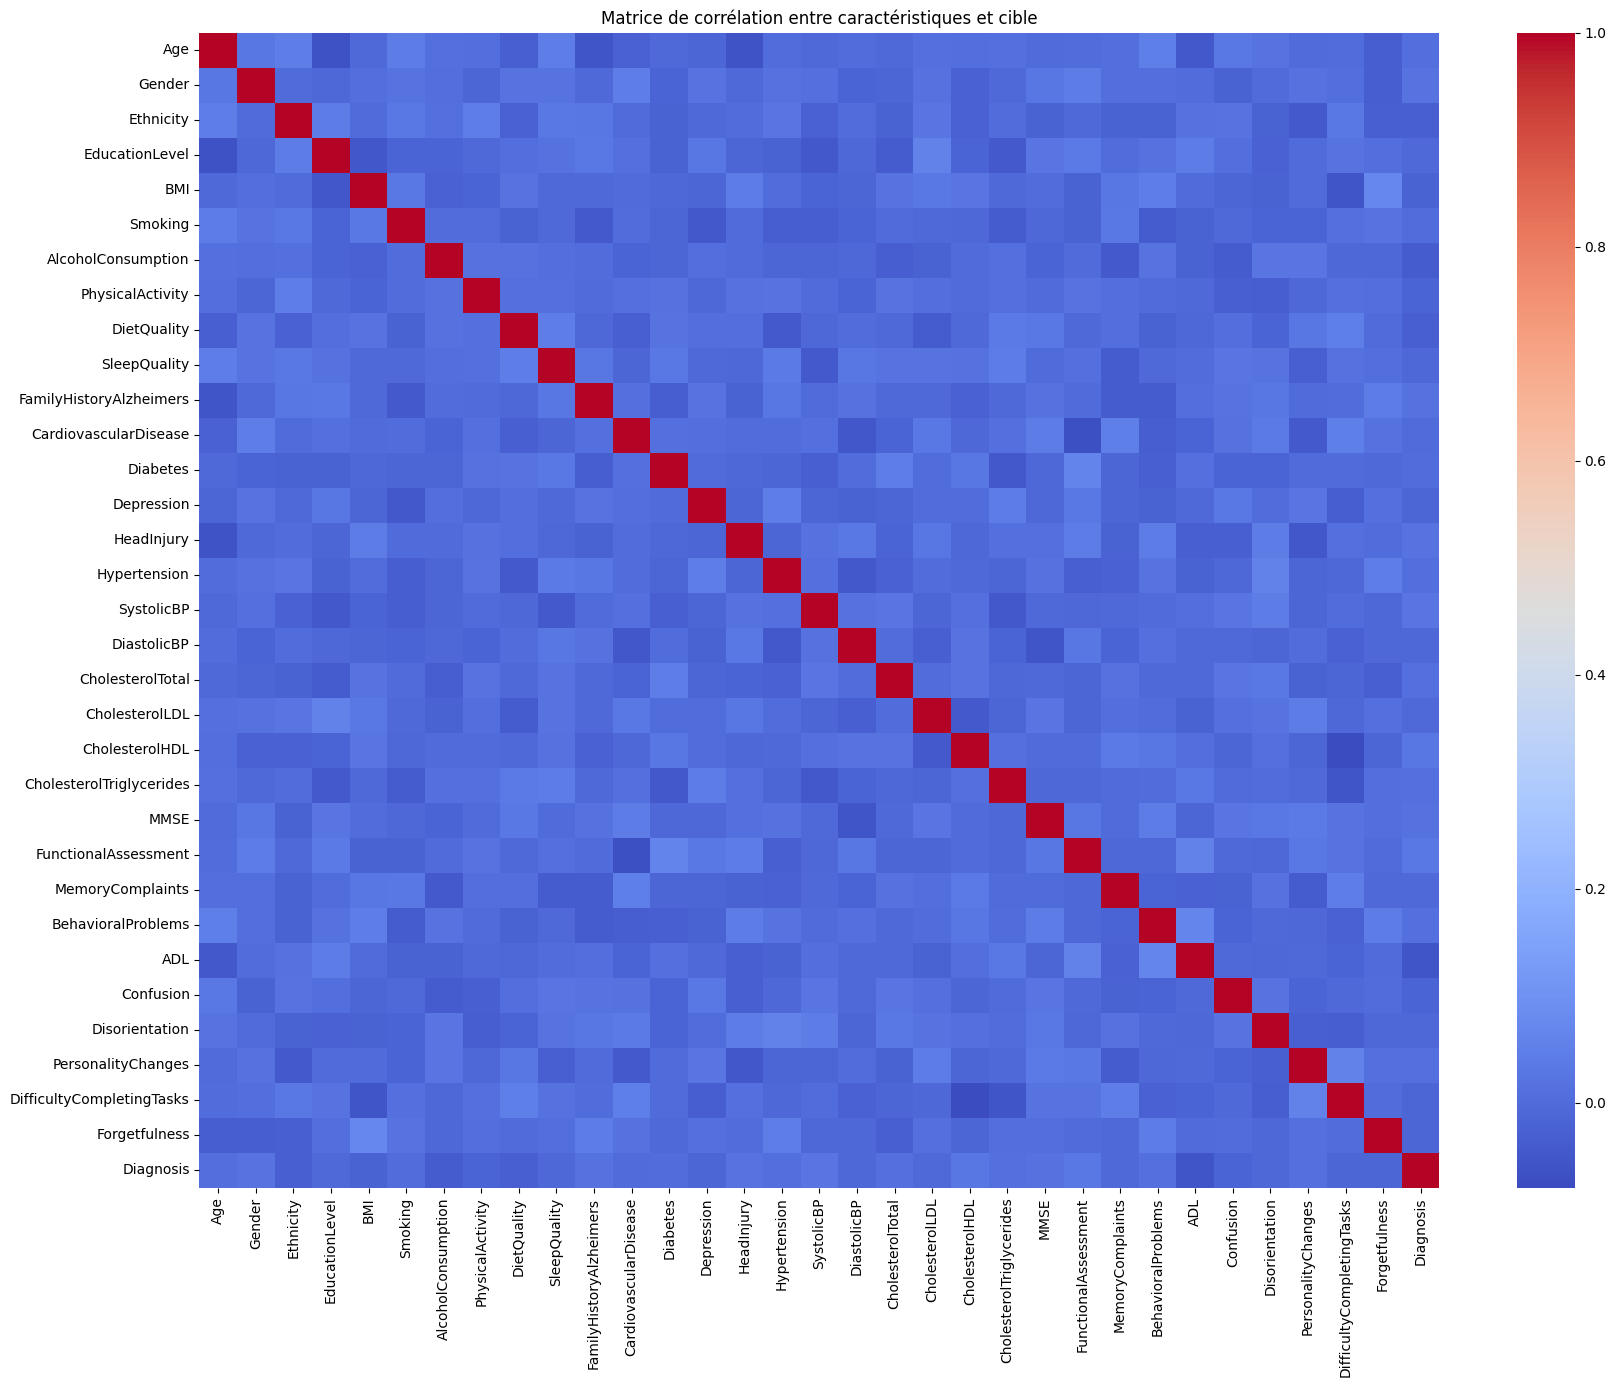


Caractéristiques corrélées avec la cible (|corrélation| > 0.1) :
[]


In [8]:
# Matrice de corrélation
corr_matrix = X_train_scaled_df.join(y_train).corr()

# Plot la matrice des corrélations
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Matrice de corrélation entre caractéristiques et cible")
plt.show()

# Identifier les caractéristiques corrélées avec la cible
correlated_features = corr_matrix[abs(corr_matrix['Diagnosis']) > 0.1].index.tolist()
if 'Diagnosis' in correlated_features:
    correlated_features.remove('Diagnosis')

print("\nCaractéristiques corrélées avec la cible (|corrélation| > 0.1) :")
print(correlated_features)

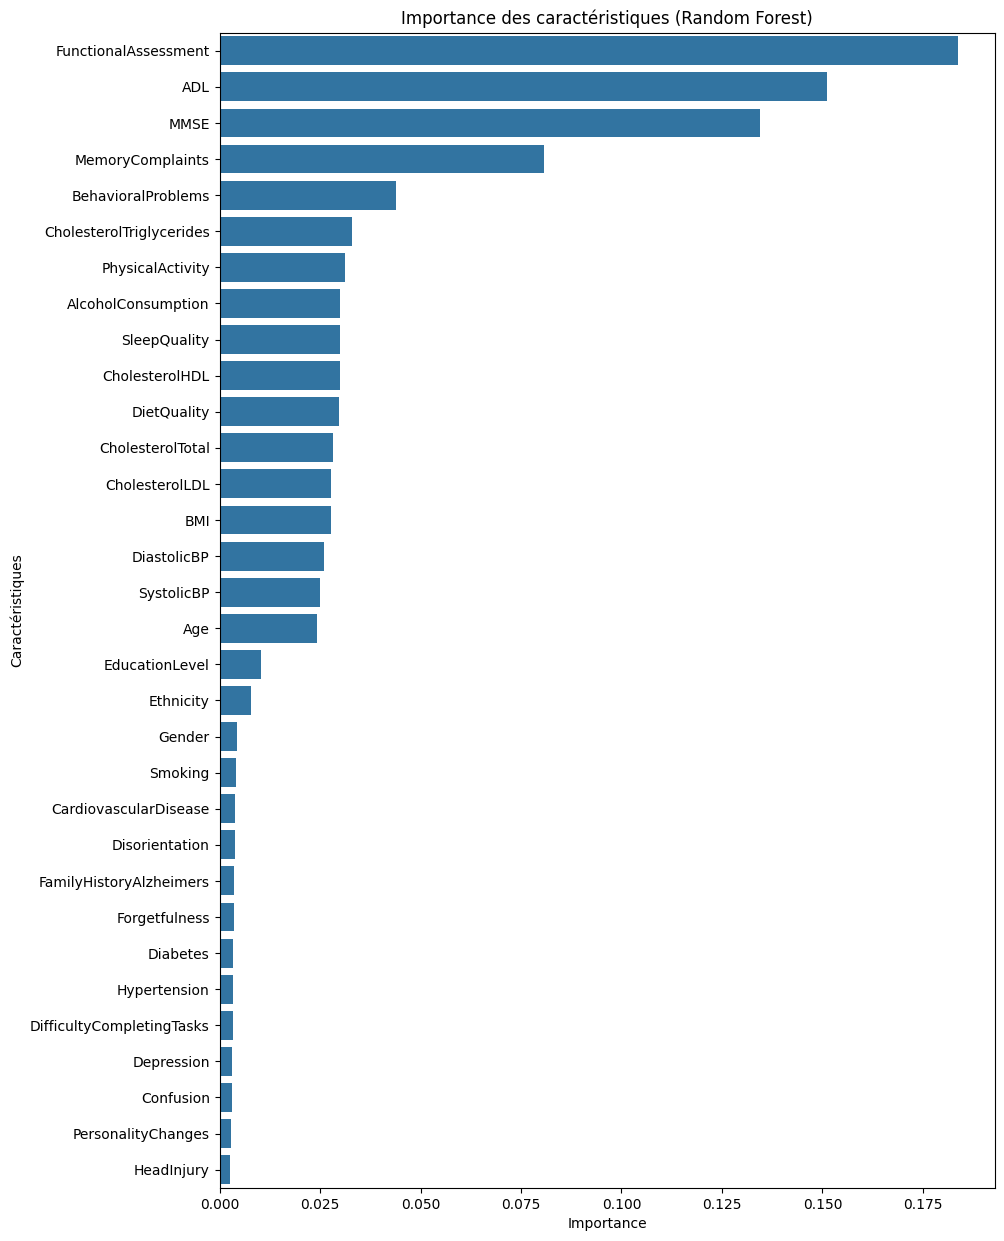


Caractéristiques sélectionnées par l'importance Random Forest :
['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'CholesterolTriglycerides', 'PhysicalActivity', 'AlcoholConsumption', 'SleepQuality', 'CholesterolHDL', 'DietQuality', 'CholesterolTotal', 'CholesterolLDL', 'BMI', 'DiastolicBP', 'SystolicBP', 'Age']


In [9]:
# Importance des caractéristiques avec Random Forest
rf_selector = RandomForestClassifier(n_estimators=100)
rf_selector.fit(X_train_scaled_df, y_train)

feature_importances = pd.Series(rf_selector.feature_importances_, 
                               index=X_train.columns).sort_values(ascending=False)

# Plot l'importance des caractéristiques
plt.figure(figsize=(10, 15))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Importance des caractéristiques (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Caractéristiques")
plt.show()

# Sélectionner les caractéristiques importantes (seuil > 0.02)
selected_features_rf = feature_importances[feature_importances > 0.02].index.tolist()
print("\nCaractéristiques sélectionnées par l'importance Random Forest :")
print(selected_features_rf)

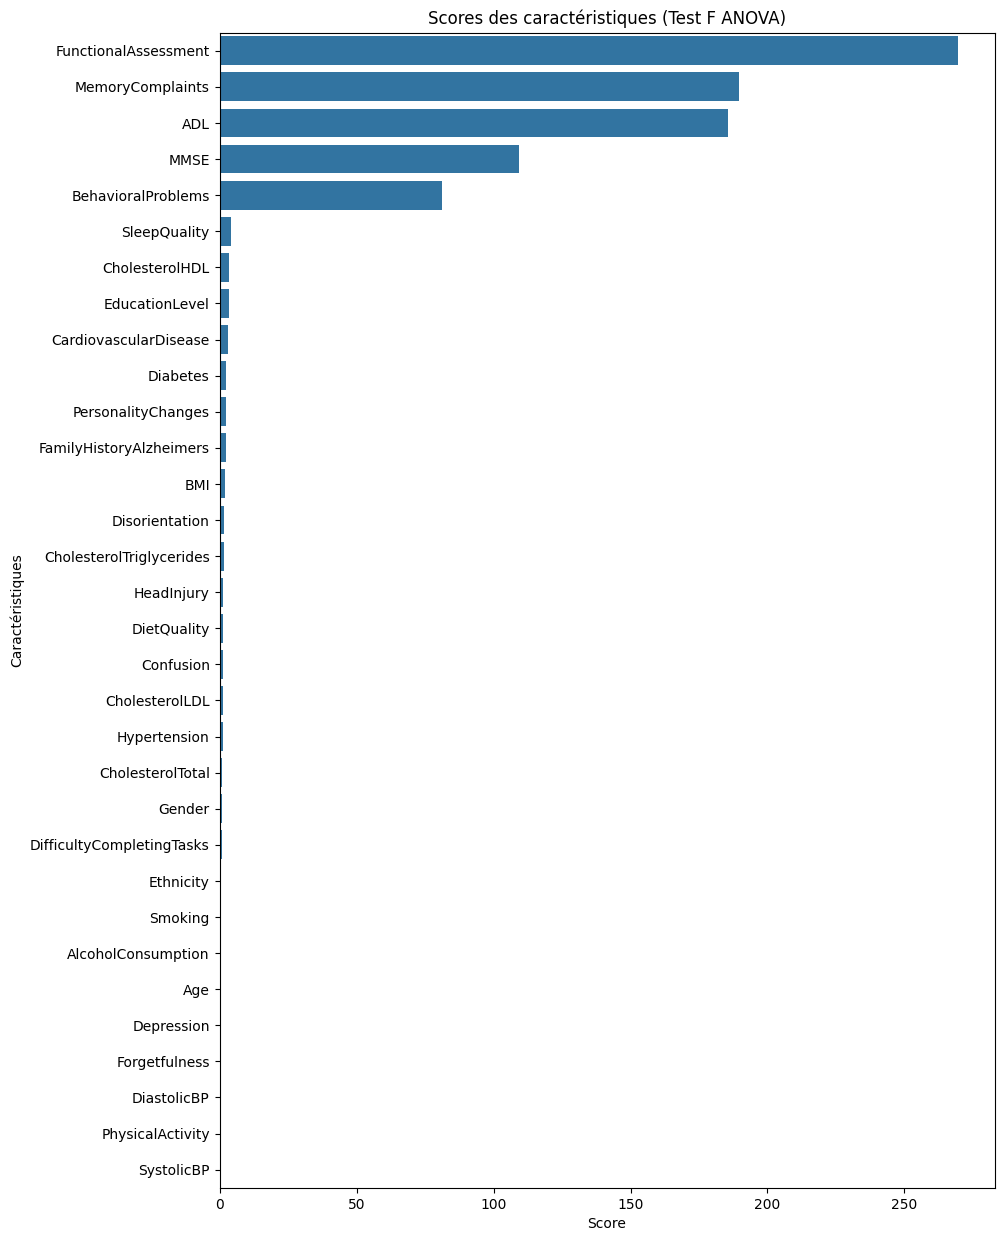


Caractéristiques sélectionnées par ANOVA :
['FunctionalAssessment', 'MemoryComplaints', 'ADL', 'MMSE', 'BehavioralProblems']


In [10]:
# Test F ANOVA pour la sélection des caractéristiques
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_train_scaled_df, y_train)

# Scores des caractéristiques
feature_scores = pd.Series(selector_anova.scores_, 
                          index=X_train.columns).sort_values(ascending=False)

# Plot les scores ANOVA
plt.figure(figsize=(10, 15))
sns.barplot(x=feature_scores.values, y=feature_scores.index)
plt.title("Scores des caractéristiques (Test F ANOVA)")
plt.xlabel("Score")
plt.ylabel("Caractéristiques")
plt.show()

# Sélectionner les caractéristiques avec des scores ANOVA élevés
selected_features_anova = feature_scores[feature_scores > 10].index.tolist()
print("\nCaractéristiques sélectionnées par ANOVA :")
print(selected_features_anova)

In [11]:
# Combiner toutes les caractéristiques sélectionnées
selected_features = list(set(correlated_features + selected_features_rf + selected_features_anova))
print("\nCaractéristiques finales sélectionnées :")
print(selected_features)

# Appliquer la sélection des caractéristiques
X_train_selected = X_train_scaled_df[selected_features]
X_test_selected = X_test_scaled_df[selected_features]

print(f"\nForme des caractéristiques sélectionnées - Entraînement : {X_train_selected.shape}")
print(f"Forme des caractéristiques sélectionnées - Test : {X_test_selected.shape}")


Caractéristiques finales sélectionnées :
['MMSE', 'ADL', 'SleepQuality', 'DietQuality', 'CholesterolHDL', 'CholesterolLDL', 'SystolicBP', 'Age', 'FunctionalAssessment', 'CholesterolTriglycerides', 'DiastolicBP', 'BehavioralProblems', 'PhysicalActivity', 'BMI', 'CholesterolTotal', 'MemoryComplaints', 'AlcoholConsumption']

Forme des caractéristiques sélectionnées - Entraînement : (1719, 17)
Forme des caractéristiques sélectionnées - Test : (430, 17)


In [12]:
# Définir les modèles
models = {
    'Régression Logistique': LogisticRegression(max_iter=10000),
    'Forêt Aléatoire': RandomForestClassifier(),
    'SVM': SVC(probability=True)
}

# Stockage des résultats
results = {}

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    """
    Évaluer les modèles
    """
    # Entraîner le modèle
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Calculer les métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Stocker les résultats
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    # Afficher les résultats
    print(f"\nRésultats pour {model_name} :")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Précision : {precision:.4f}")
    print(f"Rappel : {recall:.4f}")
    print(f"Score F1 : {f1:.4f}")
    print(f"\nRapport de classification :")
    print(results[model_name]['classification_report'])
    print(f"\nMatrice de confusion :")
    print(results[model_name]['confusion_matrix'])

In [13]:
# Évaluer chaque modèle
for model_name, model in models.items():
    print(f"\nEntraînement et évaluation de {model_name}")
    evaluate_model(model_name, model, X_train_selected, y_train, 
                  X_test_selected, y_test)


Entraînement et évaluation de Régression Logistique

Résultats pour Régression Logistique :
Accuracy : 0.8465
Précision : 0.8209
Rappel : 0.7237
Score F1 : 0.7692

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       278
           1       0.82      0.72      0.77       152

    accuracy                           0.85       430
   macro avg       0.84      0.82      0.83       430
weighted avg       0.84      0.85      0.84       430


Matrice de confusion :
[[254  24]
 [ 42 110]]

Entraînement et évaluation de Forêt Aléatoire

Résultats pour Forêt Aléatoire :
Accuracy : 0.9372
Précision : 0.9371
Rappel : 0.8816
Score F1 : 0.9085

Rapport de classification :
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92 

In [14]:
# Grilles de paramètres pour l'optimisation
param_grids = {
    'Régression Logistique': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2']
    },
    'Forêt Aléatoire': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto', 0.1, 1, 10]
    }
}

def optimize_hyperparameters(model_name, model, param_grid, X_train, y_train):
    """
    Optimiser les hyperparamètres en utilisant GridSearchCV
    """
    print(f"\nOptimisation des hyperparamètres pour {model_name}")
    
    # Validation croisée stratifiée
    cv = StratifiedKFold(n_splits=5, shuffle=True)
    
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=model, 
        param_grid=param_grid,
        scoring='f1', 
        cv=cv, 
        n_jobs=-1, 
        verbose=1
    )
    
    # Ajuster sur les données d'entraînement
    grid_search.fit(X_train, y_train)
    
    # Extraire les résultats
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    best_model = grid_search.best_estimator_
    
    # Stocker les résultats
    results[model_name]['best_params'] = best_params
    results[model_name]['best_score'] = best_score
    results[model_name]['best_model'] = best_model
    
    # Afficher les résultats
    print(f"Meilleurs paramètres : {best_params}")
    print(f"Meilleur score F1 : {best_score:.4f}")
    
    return best_model

In [15]:
# Optimiser chaque modèle
for model_name, model in models.items():
    best_model = optimize_hyperparameters(
        model_name, model, param_grids[model_name], 
        X_train_selected, y_train
    )
    
    # Ré-évaluer le modèle optimisé
    print(f"\nRé-évaluation du {model_name} optimisé")
    evaluate_model(
        f"{model_name} (optimisé)", best_model, 
        X_train_selected, y_train, X_test_selected, y_test
    )


Optimisation des hyperparamètres pour Régression Logistique
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Meilleurs paramètres : {'C': 1, 'penalty': 'l2'}
Meilleur score F1 : 0.7690

Ré-évaluation du Régression Logistique optimisé

Résultats pour Régression Logistique (optimisé) :
Accuracy : 0.8465
Précision : 0.8209
Rappel : 0.7237
Score F1 : 0.7692

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       278
           1       0.82      0.72      0.77       152

    accuracy                           0.85       430
   macro avg       0.84      0.82      0.83       430
weighted avg       0.84      0.85      0.84       430


Matrice de confusion :
[[254  24]
 [ 42 110]]

Optimisation des hyperparamètres pour Forêt Aléatoire
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

In [16]:
# Comparer les modèles optimisés
comparison_data = []

for model_name, result in results.items():
    if 'optimisé' in model_name:
        comparison_data.append({
            'Modèle': model_name,
            'Accuracy': result['accuracy'],
            'Précision': result['precision'],
            'Rappel': result['recall'],
            'Score F1': result['f1']
        })

comparison_df = pd.DataFrame(comparison_data)

print("\nComparaison des modèles optimisés :")
print(comparison_df.round(4))

# Trouver le meilleur modèle
best_model_name = comparison_df.loc[comparison_df['Score F1'].idxmax(), 'Modèle']
print(f"\nMeilleur modèle : {best_model_name}")
print(f"Meilleur score F1 : {comparison_df['Score F1'].max():.4f}")


Comparaison des modèles optimisés :
                             Modèle  Accuracy  Précision  Rappel  Score F1
0  Régression Logistique (optimisé)    0.8465     0.8209  0.7237    0.7692
1        Forêt Aléatoire (optimisé)    0.9395     0.9375  0.8882    0.9122
2                    SVM (optimisé)    0.8581     0.8370  0.7434    0.7875

Meilleur modèle : Forêt Aléatoire (optimisé)
Meilleur score F1 : 0.9122
